In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/rostat")

PRICE_DIR = BASE_DIR / "processed"
SALES_DIR = BASE_DIR / "processed_sales"

prices_long = pd.read_csv(
    PRICE_DIR / "weekly_prices_long.csv",
    parse_dates=["date"]
)

products = pd.read_csv(
    PRICE_DIR / "product_dictionary.csv"
)

sales_group_long = pd.read_csv(
    SALES_DIR / "sales_dynamics_by_existing_categories.csv",
    parse_dates=["period_end"]
)

In [3]:
prices = prices_long.merge(
    products[
        [
            "product_code",
            "product_group_code",
            "product_group_name"
        ]
    ],
    on="product_code",
    how="left"
)

prices["year"] = prices["date"].dt.year
prices["quarter"] = prices["date"].dt.quarter

price_quarter = (
    prices
    .groupby(
        [
            "year",
            "quarter",
            "product_group_code",
            "product_group_name"
        ],
        as_index=False
    )
    .agg(
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        n_price_products=("product_code", "nunique")
    )
)

quarter_month_map = {
    1: 3,
    2: 6,
    3: 9,
    4: 12
}

price_quarter["period_end"] = price_quarter.apply(
    lambda row: pd.Timestamp(
        year=int(row["year"]),
        month=quarter_month_map[int(row["quarter"])],
        day=1
    ) + pd.offsets.MonthEnd(0),
    axis=1
)

In [4]:
arimax_data = sales_group_long.merge(
    price_quarter[
        [
            "period_end",
            "year",
            "quarter",
            "product_group_code",
            "product_group_name",
            "mean_price",
            "median_price",
            "n_price_products"
        ]
    ],
    on=[
        "period_end",
        "year",
        "quarter",
        "product_group_code",
        "product_group_name"
    ],
    how="inner"
)

arimax_data = arimax_data.sort_values(
    ["product_group_code", "period_end"]
).reset_index(drop=True)

arimax_data.head()

,period_end,year,quarter,product_group_code,product_group_name,sales_quarter_thousand_rub,sales_cumulative_thousand_rub,n_sales_products,mean_price,median_price,n_price_products
0,2017-03-31,2017,1,G01,"Хлеб, крупы, мука и макаронные изделия",2.617199e+08,2.617199e+08,4,67.500104,65.115,8
1,2017-06-30,2017,2,G01,"Хлеб, крупы, мука и макаронные изделия",2.578767e+08,5.195966e+08,4,66.311442,65.135,8
2,2017-09-30,2017,3,G01,"Хлеб, крупы, мука и макаронные изделия",3.008927e+08,8.204893e+08,4,65.351538,63.610,8
3,2017-12-31,2017,4,G01,"Хлеб, крупы, мука и макаронные изделия",3.555661e+08,1.176055e+09,4,64.448750,62.690,8
4,2018-03-31,2018,1,G01,"Хлеб, крупы, мука и макаронные изделия",2.671137e+08,2.671137e+08,4,63.500521,59.165,8


In [5]:
arimax_coverage = (
    arimax_data
    .groupby(["product_group_code", "product_group_name"], as_index=False)
    .agg(
        n_obs=("period_end", "nunique"),
        start_date=("period_end", "min"),
        end_date=("period_end", "max"),
        n_years=("year", "nunique"),
        n_sales_products=("n_sales_products", "max"),
        n_price_products=("n_price_products", "max"),
        missing_sales=("sales_quarter_thousand_rub", lambda x: x.isna().sum()),
        missing_mean_price=("mean_price", lambda x: x.isna().sum()),
        missing_median_price=("median_price", lambda x: x.isna().sum())
    )
    .sort_values("n_obs", ascending=False)
)

display(arimax_coverage)

,product_group_code,product_group_name,n_obs,start_date,end_date,n_years,n_sales_products,n_price_products,missing_sales,missing_mean_price,missing_median_price
0,G01,"Хлеб, крупы, мука и макаронные изделия",32,2017-03-31,2025-12-31,8,4,8,0,0,0
1,G02,Молочная продукция и яйца,32,2017-03-31,2025-12-31,8,6,4,0,0,0
2,G03,"Мясо, птица, рыба и колбасные изделия",32,2017-03-31,2025-12-31,8,7,8,0,0,0
3,G04,"Овощи, фрукты и картофель",32,2017-03-31,2025-12-31,8,4,7,0,0,0
4,G05,"Бакалея, масло, сахар, чай, соль",32,2017-03-31,2025-12-31,8,11,4,0,0,0
5,G07,"Товары для дома, гигиены и бытовая химия",32,2017-03-31,2025-12-31,8,5,4,0,0,0
6,G10,Топливо и транспортные товары,32,2017-03-31,2025-12-31,8,10,5,0,0,0
7,G99,Прочее,32,2017-03-31,2025-12-31,8,33,6,0,0,0


In [6]:
arimax_coverage["arimax_status"] = np.select(
    [
        arimax_coverage["n_obs"] >= 32,
        arimax_coverage["n_obs"].between(24, 31),
        arimax_coverage["n_obs"] < 24
    ],
    [
        "достаточно для простой SARIMAX",
        "минимально допустимо, нужна осторожность",
        "слишком мало наблюдений"
    ],
    default="проверить"
)

display(arimax_coverage)

,product_group_code,product_group_name,n_obs,start_date,end_date,n_years,n_sales_products,n_price_products,missing_sales,missing_mean_price,missing_median_price,arimax_status
0,G01,"Хлеб, крупы, мука и макаронные изделия",32,2017-03-31,2025-12-31,8,4,8,0,0,0,достаточно для простой SARIMAX
1,G02,Молочная продукция и яйца,32,2017-03-31,2025-12-31,8,6,4,0,0,0,достаточно для простой SARIMAX
2,G03,"Мясо, птица, рыба и колбасные изделия",32,2017-03-31,2025-12-31,8,7,8,0,0,0,достаточно для простой SARIMAX
3,G04,"Овощи, фрукты и картофель",32,2017-03-31,2025-12-31,8,4,7,0,0,0,достаточно для простой SARIMAX
4,G05,"Бакалея, масло, сахар, чай, соль",32,2017-03-31,2025-12-31,8,11,4,0,0,0,достаточно для простой SARIMAX
5,G07,"Товары для дома, гигиены и бытовая химия",32,2017-03-31,2025-12-31,8,5,4,0,0,0,достаточно для простой SARIMAX
6,G10,Топливо и транспортные товары,32,2017-03-31,2025-12-31,8,10,5,0,0,0,достаточно для простой SARIMAX
7,G99,Прочее,32,2017-03-31,2025-12-31,8,33,6,0,0,0,достаточно для простой SARIMAX


In [7]:
def check_quarter_gaps(df):
    results = []

    for group_code, group_df in df.groupby("product_group_code"):
        group_name = group_df["product_group_name"].iloc[0]
        
        group_df = group_df.sort_values("period_end")
        
        full_range = pd.period_range(
            start=group_df["period_end"].min(),
            end=group_df["period_end"].max(),
            freq="Q"
        ).to_timestamp(how="end").normalize()
        
        actual_dates = group_df["period_end"].dt.normalize().unique()
        
        missing_dates = sorted(set(full_range) - set(actual_dates))
        
        results.append({
            "product_group_code": group_code,
            "product_group_name": group_name,
            "expected_quarters": len(full_range),
            "actual_quarters": group_df["period_end"].nunique(),
            "missing_quarters_count": len(missing_dates),
            "missing_quarters": ", ".join([str(d.date()) for d in missing_dates[:12]])
        })
    
    return pd.DataFrame(results)

gap_check = check_quarter_gaps(arimax_data)

display(gap_check)

,product_group_code,product_group_name,expected_quarters,actual_quarters,missing_quarters_count,missing_quarters
0,G01,"Хлеб, крупы, мука и макаронные изделия",36,32,4,"2021-03-31, 2021-06-30, 2021-09-30, 2021-12-31"
1,G02,Молочная продукция и яйца,36,32,4,"2021-03-31, 2021-06-30, 2021-09-30, 2021-12-31"
2,G03,"Мясо, птица, рыба и колбасные изделия",36,32,4,"2021-03-31, 2021-06-30, 2021-09-30, 2021-12-31"
3,G04,"Овощи, фрукты и картофель",36,32,4,"2021-03-31, 2021-06-30, 2021-09-30, 2021-12-31"
4,G05,"Бакалея, масло, сахар, чай, соль",36,32,4,"2021-03-31, 2021-06-30, 2021-09-30, 2021-12-31"
5,G07,"Товары для дома, гигиены и бытовая химия",36,32,4,"2021-03-31, 2021-06-30, 2021-09-30, 2021-12-31"
6,G10,Топливо и транспортные товары,36,32,4,"2021-03-31, 2021-06-30, 2021-09-30, 2021-12-31"
7,G99,Прочее,36,32,4,"2021-03-31, 2021-06-30, 2021-09-30, 2021-12-31"


In [8]:

arimax_data = arimax_data.copy()
arimax_data["period_end"] = pd.to_datetime(arimax_data["period_end"])

arimax_data = arimax_data.sort_values(
    ["product_group_code", "period_end"]
).reset_index(drop=True)

arimax_data.head()

,period_end,year,quarter,product_group_code,product_group_name,sales_quarter_thousand_rub,sales_cumulative_thousand_rub,n_sales_products,mean_price,median_price,n_price_products
0,2017-03-31,2017,1,G01,"Хлеб, крупы, мука и макаронные изделия",2.617199e+08,2.617199e+08,4,67.500104,65.115,8
1,2017-06-30,2017,2,G01,"Хлеб, крупы, мука и макаронные изделия",2.578767e+08,5.195966e+08,4,66.311442,65.135,8
2,2017-09-30,2017,3,G01,"Хлеб, крупы, мука и макаронные изделия",3.008927e+08,8.204893e+08,4,65.351538,63.610,8
3,2017-12-31,2017,4,G01,"Хлеб, крупы, мука и макаронные изделия",3.555661e+08,1.176055e+09,4,64.448750,62.690,8
4,2018-03-31,2018,1,G01,"Хлеб, крупы, мука и макаронные изделия",2.671137e+08,2.671137e+08,4,63.500521,59.165,8


In [9]:
full_quarters = pd.period_range(
    start="2017Q1",
    end="2025Q4",
    freq="Q"
).to_timestamp(how="end").normalize()

groups = (
    arimax_data[
        ["product_group_code", "product_group_name"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

full_grid = (
    groups
    .assign(key=1)
    .merge(
        pd.DataFrame({"period_end": full_quarters, "key": 1}),
        on="key",
        how="outer"
    )
    .drop(columns="key")
)

full_grid["year"] = full_grid["period_end"].dt.year
full_grid["quarter"] = full_grid["period_end"].dt.quarter

full_grid.head()

,product_group_code,product_group_name,period_end,year,quarter
0,G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2017,1
1,G01,"Хлеб, крупы, мука и макаронные изделия",2017-06-30,2017,2
2,G01,"Хлеб, крупы, мука и макаронные изделия",2017-09-30,2017,3
3,G01,"Хлеб, крупы, мука и макаронные изделия",2017-12-31,2017,4
4,G01,"Хлеб, крупы, мука и макаронные изделия",2018-03-31,2018,1


In [10]:
arimax_full = full_grid.merge(
    arimax_data,
    on=[
        "product_group_code",
        "product_group_name",
        "period_end",
        "year",
        "quarter"
    ],
    how="left"
)

arimax_full["is_imputed"] = arimax_full["sales_quarter_thousand_rub"].isna()

arimax_full = arimax_full.sort_values(
    ["product_group_code", "period_end"]
).reset_index(drop=True)

arimax_full.head()

,product_group_code,product_group_name,period_end,year,quarter,sales_quarter_thousand_rub,sales_cumulative_thousand_rub,n_sales_products,mean_price,median_price,n_price_products,is_imputed
0,G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2017,1,2.617199e+08,2.617199e+08,4.0,67.500104,65.115,8.0,False
1,G01,"Хлеб, крупы, мука и макаронные изделия",2017-06-30,2017,2,2.578767e+08,5.195966e+08,4.0,66.311442,65.135,8.0,False
2,G01,"Хлеб, крупы, мука и макаронные изделия",2017-09-30,2017,3,3.008927e+08,8.204893e+08,4.0,65.351538,63.610,8.0,False
3,G01,"Хлеб, крупы, мука и макаронные изделия",2017-12-31,2017,4,3.555661e+08,1.176055e+09,4.0,64.448750,62.690,8.0,False
4,G01,"Хлеб, крупы, мука и макаронные изделия",2018-03-31,2018,1,2.671137e+08,2.671137e+08,4.0,63.500521,59.165,8.0,False


In [11]:
cols_to_interpolate = [
    "sales_quarter_thousand_rub",
    "sales_cumulative_thousand_rub",
    "mean_price",
    "median_price",
    "n_price_products",
    "n_sales_products"
]

for col in cols_to_interpolate:
    if col in arimax_full.columns:
        arimax_full[col] = (
            arimax_full
            .groupby("product_group_code")[col]
            .transform(lambda x: x.interpolate(method="linear"))
        )

In [12]:
arimax_full = arimax_full.sort_values(
    ["product_group_code", "period_end"]
).copy()

arimax_full["price_index"] = (
    arimax_full["median_price"] /
    arimax_full.groupby("product_group_code")["median_price"].transform("first")
) * 100

arimax_full["sales_index"] = (
    arimax_full["sales_quarter_thousand_rub"] /
    arimax_full.groupby("product_group_code")["sales_quarter_thousand_rub"].transform("first")
) * 100

In [13]:
check_after_fill = (
    arimax_full
    .groupby(["product_group_code", "product_group_name"], as_index=False)
    .agg(
        n_obs=("period_end", "nunique"),
        start_date=("period_end", "min"),
        end_date=("period_end", "max"),
        missing_sales=("sales_quarter_thousand_rub", lambda x: x.isna().sum()),
        missing_price=("median_price", lambda x: x.isna().sum()),
        imputed_points=("is_imputed", "sum")
    )
)

display(check_after_fill)

,product_group_code,product_group_name,n_obs,start_date,end_date,missing_sales,missing_price,imputed_points
0,G01,"Хлеб, крупы, мука и макаронные изделия",36,2017-03-31,2025-12-31,0,0,4
1,G02,Молочная продукция и яйца,36,2017-03-31,2025-12-31,0,0,4
2,G03,"Мясо, птица, рыба и колбасные изделия",36,2017-03-31,2025-12-31,0,0,4
3,G04,"Овощи, фрукты и картофель",36,2017-03-31,2025-12-31,0,0,4
4,G05,"Бакалея, масло, сахар, чай, соль",36,2017-03-31,2025-12-31,0,0,4
5,G07,"Товары для дома, гигиены и бытовая химия",36,2017-03-31,2025-12-31,0,0,4
6,G10,Топливо и транспортные товары,36,2017-03-31,2025-12-31,0,0,4
7,G99,Прочее,36,2017-03-31,2025-12-31,0,0,4


In [14]:
imputed_2021 = arimax_full[
    arimax_full["is_imputed"]
].copy()

display(
    imputed_2021[
        [
            "period_end",
            "year",
            "quarter",
            "product_group_code",
            "product_group_name",
            "sales_quarter_thousand_rub",
            "median_price",
            "price_index",
            "sales_index"
        ]
    ].sort_values(["product_group_code", "period_end"])
)

,period_end,year,quarter,product_group_code,product_group_name,sales_quarter_thousand_rub,median_price,price_index,sales_index
16,2021-03-31,2021,1,G01,"Хлеб, крупы, мука и макаронные изделия",3.662149e+08,82.569,126.804884,139.926276
17,2021-06-30,2021,2,G01,"Хлеб, крупы, мука и макаронные изделия",3.701051e+08,85.248,130.919143,141.412669
18,2021-09-30,2021,3,G01,"Хлеб, крупы, мука и макаронные изделия",3.739953e+08,87.927,135.033402,142.899061
19,2021-12-31,2021,4,G01,"Хлеб, крупы, мука и макаронные изделия",3.778854e+08,90.606,139.147662,144.385454
52,2021-03-31,2021,1,G02,Молочная продукция и яйца,6.829762e+08,152.123,120.914872,122.483558
53,2021-06-30,2021,2,G02,Молочная продукция и яйца,7.114190e+08,156.261,124.203958,127.584435
54,2021-09-30,2021,3,G02,Молочная продукция и яйца,7.398618e+08,160.399,127.493045,132.685313
55,2021-12-31,2021,4,G02,Молочная продукция и яйца,7.683046e+08,164.537,130.782132,137.786190
88,2021-03-31,2021,1,G03,"Мясо, птица, рыба и колбасные изделия",1.708864e+09,383.230,118.054957,131.563780
89,2021-06-30,2021,2,G03,"Мясо, птица, рыба и колбасные изделия",1.722025e+09,395.780,121.921015,132.577062


In [15]:
OUT_ARIMAX_DATA = SALES_DIR / "arimax_category_dataset.csv"

arimax_full.to_csv(
    OUT_ARIMAX_DATA,
    index=False,
    encoding="utf-8-sig"
)

print("ARIMAX dataset сохранён:")
print(OUT_ARIMAX_DATA)

ARIMAX dataset сохранён:
/content/drive/MyDrive/rostat/processed_sales/arimax_category_dataset.csv


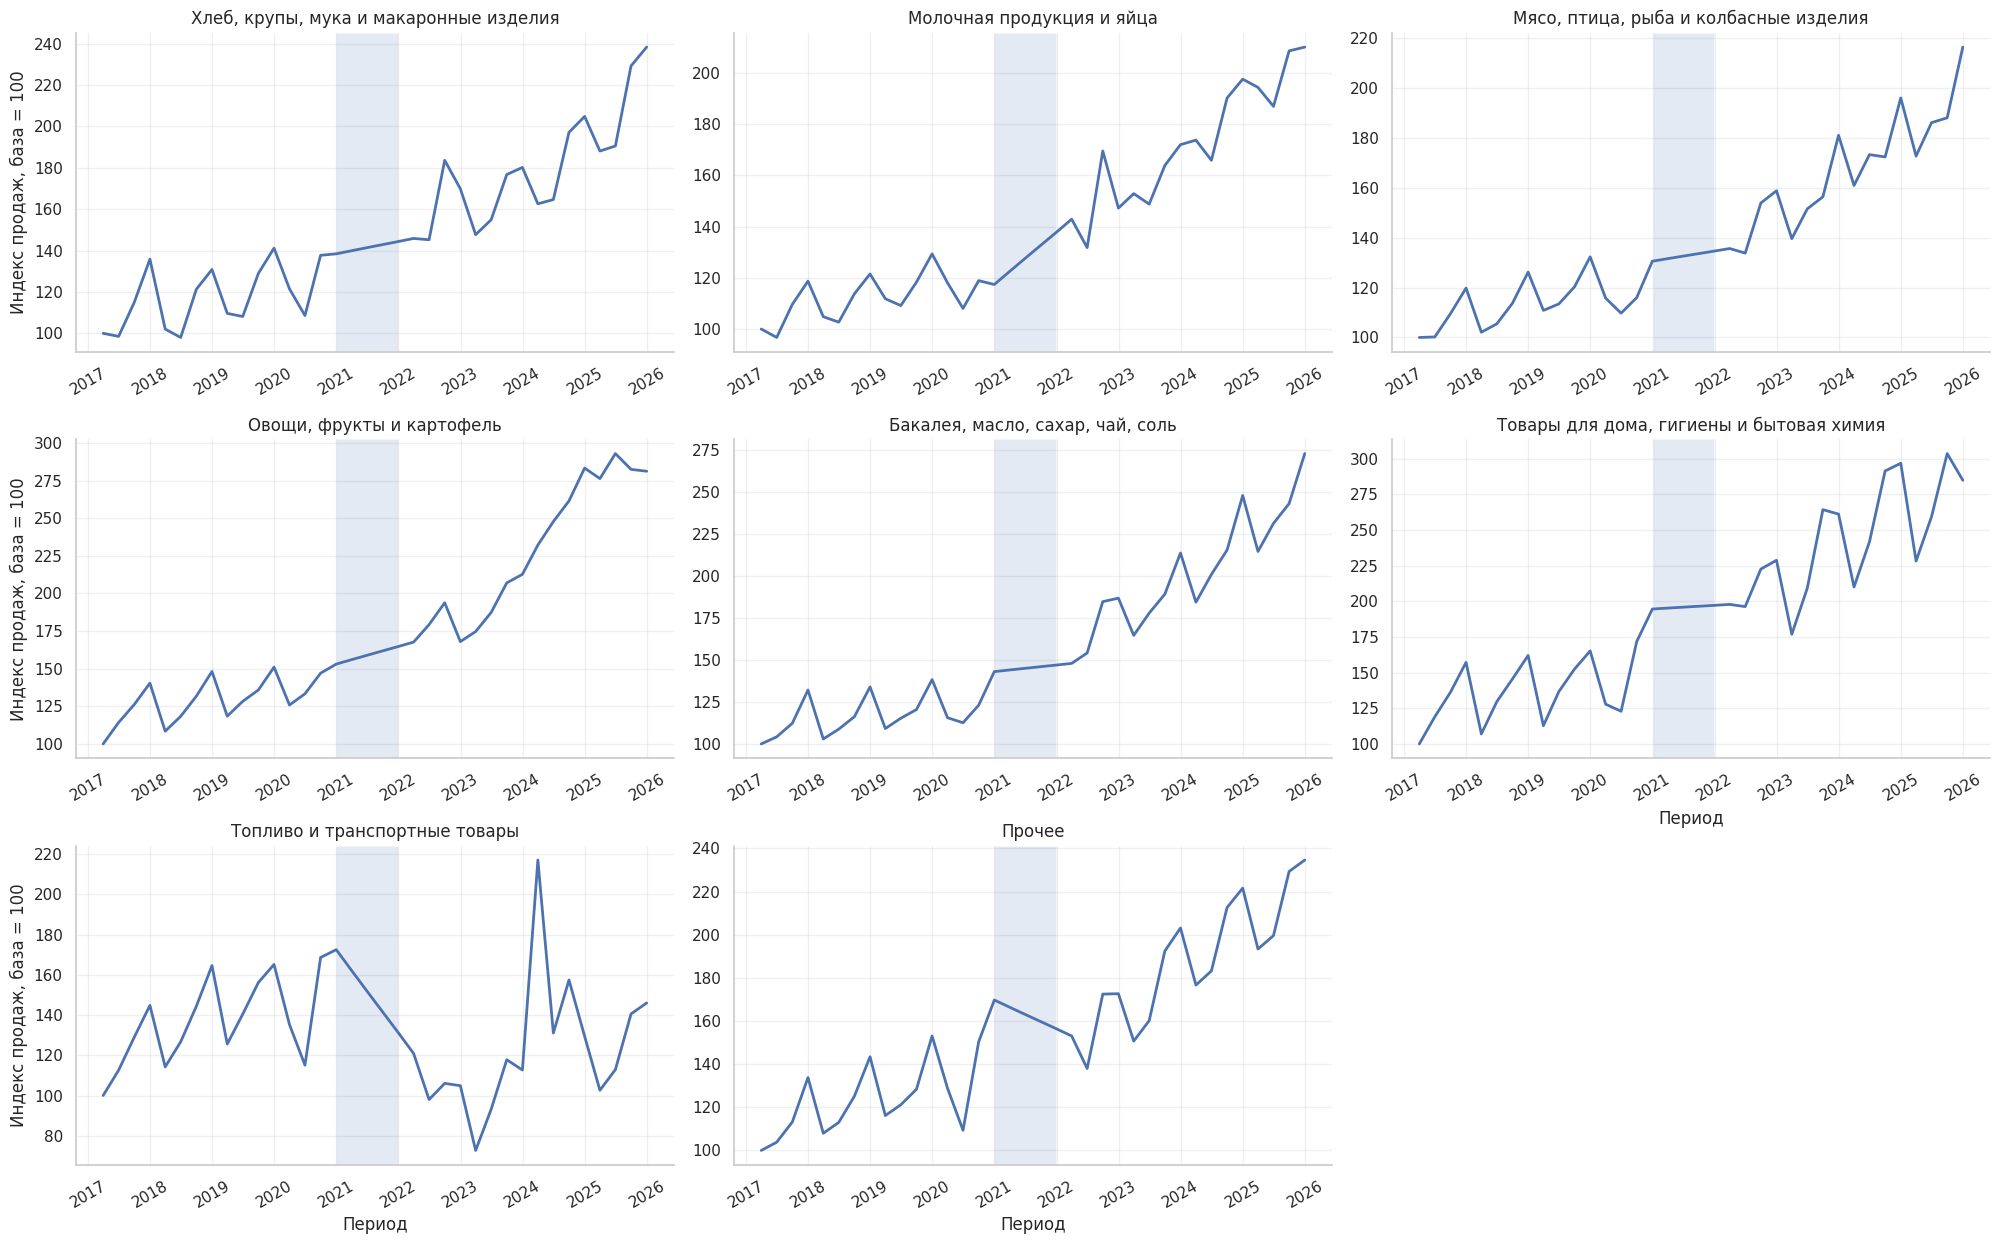

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    arimax_full,
    col="product_group_name",
    col_wrap=3,
    height=4.2,
    aspect=1.6,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="period_end",
    y="sales_index",
    linewidth=2
)

g.set_axis_labels("Период", "Индекс продаж, база = 100")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.axvspan(
        pd.Timestamp("2021-01-01"),
        pd.Timestamp("2021-12-31"),
        alpha=0.15,
        label="Интерполированный 2021"
    )
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [33]:
BASE_DIR = Path("/content/drive/MyDrive/rostat")
SALES_DIR = BASE_DIR / "processed_sales"

arimax_data = pd.read_csv(
    SALES_DIR / "arimax_category_dataset.csv",
    parse_dates=["period_end"]
)

arimax_data = arimax_data.sort_values(
    ["product_group_code", "period_end"]
).copy()

arimax_data["price_index_lag1"] = (
    arimax_data
    .groupby("product_group_code")["price_index"]
    .shift(1)
)

arimax_data = arimax_data.dropna(subset=["price_index_lag1"]).copy()

arimax_data.head()

,product_group_code,product_group_name,period_end,year,quarter,sales_quarter_thousand_rub,sales_cumulative_thousand_rub,n_sales_products,mean_price,median_price,n_price_products,is_imputed,price_index,sales_index,price_index_lag1
1,G01,"Хлеб, крупы, мука и макаронные изделия",2017-06-30,2017,2,2.578767e+08,5.195966e+08,4.0,66.311442,65.135,8.0,False,100.030715,98.531578,100.000000
2,G01,"Хлеб, крупы, мука и макаронные изделия",2017-09-30,2017,3,3.008927e+08,8.204893e+08,4.0,65.351538,63.610,8.0,False,97.688705,114.967455,100.030715
3,G01,"Хлеб, крупы, мука и макаронные изделия",2017-12-31,2017,4,3.555661e+08,1.176055e+09,4.0,64.448750,62.690,8.0,False,96.275820,135.857510,97.688705
4,G01,"Хлеб, крупы, мука и макаронные изделия",2018-03-31,2018,1,2.671137e+08,2.671137e+08,4.0,63.500521,59.165,8.0,False,90.862321,102.060902,96.275820
5,G01,"Хлеб, крупы, мука и макаронные изделия",2018-06-30,2018,2,2.564807e+08,5.235944e+08,4.0,63.062500,56.750,8.0,False,87.153498,97.998164,90.862321


In [21]:
print("Размер данных:", arimax_data.shape)
print("Период:", arimax_data["period_end"].min(), "—", arimax_data["period_end"].max())
print("Категорий:", arimax_data["product_group_code"].nunique())

display(
    arimax_data
    .groupby(["product_group_code", "product_group_name"], as_index=False)
    .agg(
        n_obs=("period_end", "nunique"),
        start_date=("period_end", "min"),
        end_date=("period_end", "max"),
        imputed_points=("is_imputed", "sum")
    )
)

Размер данных: (288, 14)
Период: 2017-03-31 00:00:00 — 2025-12-31 00:00:00
Категорий: 8


,product_group_code,product_group_name,n_obs,start_date,end_date,imputed_points
0,G01,"Хлеб, крупы, мука и макаронные изделия",36,2017-03-31,2025-12-31,4
1,G02,Молочная продукция и яйца,36,2017-03-31,2025-12-31,4
2,G03,"Мясо, птица, рыба и колбасные изделия",36,2017-03-31,2025-12-31,4
3,G04,"Овощи, фрукты и картофель",36,2017-03-31,2025-12-31,4
4,G05,"Бакалея, масло, сахар, чай, соль",36,2017-03-31,2025-12-31,4
5,G07,"Товары для дома, гигиены и бытовая химия",36,2017-03-31,2025-12-31,4
6,G10,Топливо и транспортные товары,36,2017-03-31,2025-12-31,4
7,G99,Прочее,36,2017-03-31,2025-12-31,4


In [22]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100


def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0

    return np.mean(
        np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]
    ) * 100


def calculate_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred)
    }

In [23]:
def run_seasonal_naive_category(category_df, validation_size=4):
    df = category_df.copy().sort_values("period_end").reset_index(drop=True)

    train_df = df.iloc[:-validation_size].copy()
    valid_df = df.iloc[-validation_size:].copy()

    # Для последних 4 кварталов берём значения за 4 квартала до них
    yhat = df["sales_index"].iloc[-validation_size - 4:-4].values

    pred = valid_df[[
        "period_end",
        "product_group_code",
        "product_group_name",
        "sales_index"
    ]].copy()

    pred["y"] = pred["sales_index"]
    pred["yhat"] = yhat
    pred["model"] = "Seasonal Naive"
    pred["set_type"] = "validation"

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "model": "Seasonal Naive",
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "validation_size": validation_size,
        "train_start": train_df["period_end"].min(),
        "train_end": train_df["period_end"].max(),
        "valid_start": valid_df["period_end"].min(),
        "valid_end": valid_df["period_end"].max()
    })

    return pred, metrics

In [34]:
sarimax_configs = [
    {
        "model": "SARIMA (0,1,0)(0,1,1,4)",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 1, 4),
        "exog_cols": []
    },
    {
        "model": "SARIMA (1,1,0)(0,1,1,4)",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 1, 4),
        "exog_cols": []
    },
    {
        "model": "SARIMAX (0,1,0)(0,1,1,4) + price_index_lag1",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 1, 4),
        "exog_cols": ["price_index_lag1"]
    },
    {
        "model": "SARIMAX (1,1,0)(0,1,1,4) + price_index_lag1",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 1, 4),
        "exog_cols": ["price_index_lag1"]
    }
]

In [35]:
def run_sarimax_category(
    category_df,
    config,
    validation_size=4,
    y_col="sales_index"
):
    df = category_df.copy().sort_values("period_end").reset_index(drop=True)

    train_df = df.iloc[:-validation_size].copy()
    valid_df = df.iloc[-validation_size:].copy()

    y_train = np.log1p(train_df[y_col])
    y_valid = valid_df[y_col].values

    exog_cols = config["exog_cols"]

    if len(exog_cols) > 0:
        exog_train = train_df[exog_cols].copy()
        exog_valid = valid_df[exog_cols].copy()

        # Стандартизация по train, чтобы не было утечки данных
        exog_mean = exog_train.mean()
        exog_std = exog_train.std().replace(0, 1)

        exog_train_scaled = (exog_train - exog_mean) / exog_std
        exog_valid_scaled = (exog_valid - exog_mean) / exog_std
    else:
        exog_train_scaled = None
        exog_valid_scaled = None

    model = SARIMAX(
        y_train,
        exog=exog_train_scaled,
        order=config["order"],
        seasonal_order=config["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(
        disp=False,
        maxiter=300
    )

    forecast_log = result.forecast(
        steps=len(valid_df),
        exog=exog_valid_scaled
    )

    yhat = np.expm1(forecast_log)
    yhat = np.maximum(yhat, 0)

    pred = valid_df[[
        "period_end",
        "product_group_code",
        "product_group_name",
        y_col
    ]].copy()

    pred["y"] = y_valid
    pred["yhat"] = yhat
    pred["model"] = config["model"]
    pred["set_type"] = "validation"

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "model": config["model"],
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "validation_size": validation_size,
        "train_start": train_df["period_end"].min(),
        "train_end": train_df["period_end"].max(),
        "valid_start": valid_df["period_end"].min(),
        "valid_end": valid_df["period_end"].max(),
        "AIC": result.aic,
        "BIC": result.bic
    })

    return result, pred, metrics

In [36]:
all_metrics = []
all_predictions = []
all_models = {}

validation_size = 4

for group_code, category_df in arimax_data.groupby("product_group_code"):
    group_name = category_df["product_group_name"].iloc[0]

    print("=" * 100)
    print(f"Категория: {group_code} — {group_name}")

    category_df = category_df.sort_values("period_end").copy()

    # Проверка минимального числа наблюдений
    if category_df["period_end"].nunique() < 24:
        print("Пропуск: слишком мало наблюдений")
        continue

    # Baseline
    try:
        naive_pred, naive_metrics = run_seasonal_naive_category(
            category_df,
            validation_size=validation_size
        )

        all_metrics.append(naive_metrics)
        all_predictions.append(naive_pred)

        print(
            f"Seasonal Naive | "
            f"MAPE={naive_metrics['MAPE']:.3f}, "
            f"RMSE={naive_metrics['RMSE']:.3f}"
        )

    except Exception as e:
        print("Ошибка Seasonal Naive:", e)

    # SARIMA / SARIMAX
    for config in sarimax_configs:
        try:
            result, pred, metrics = run_sarimax_category(
                category_df=category_df,
                config=config,
                validation_size=validation_size
            )

            all_metrics.append(metrics)
            all_predictions.append(pred)

            model_key = f"{group_code}_{config['model']}"
            all_models[model_key] = result

            print(
                f"{config['model']} | "
                f"MAPE={metrics['MAPE']:.3f}, "
                f"RMSE={metrics['RMSE']:.3f}"
            )

        except Exception as e:
            print(f"Ошибка {config['model']}: {e}")

model_metrics_df = pd.DataFrame(all_metrics)
model_predictions_df = pd.concat(all_predictions, ignore_index=True)

model_metrics_df.head()

Категория: G01 — Хлеб, крупы, мука и макаронные изделия
Seasonal Naive | MAPE=13.804, RMSE=29.481
SARIMA (0,1,0)(0,1,1,4) | MAPE=2.540, RMSE=7.094
SARIMA (1,1,0)(0,1,1,4) | MAPE=3.150, RMSE=8.064
SARIMAX (0,1,0)(0,1,1,4) + price_index_lag1 | MAPE=2.732, RMSE=7.189
SARIMAX (1,1,0)(0,1,1,4) + price_index_lag1 | MAPE=1.919, RMSE=4.690
Категория: G02 — Молочная продукция и яйца
Seasonal Naive | MAPE=9.162, RMSE=18.461
SARIMA (0,1,0)(0,1,1,4) | MAPE=2.563, RMSE=5.763
SARIMA (1,1,0)(0,1,1,4) | MAPE=1.286, RMSE=3.332
SARIMAX (0,1,0)(0,1,1,4) + price_index_lag1 | MAPE=6.550, RMSE=14.613
SARIMAX (1,1,0)(0,1,1,4) + price_index_lag1 | MAPE=3.614, RMSE=8.505
Категория: G03 — Мясо, птица, рыба и колбасные изделия
Seasonal Naive | MAPE=7.863, RMSE=15.514
SARIMA (0,1,0)(0,1,1,4) | MAPE=2.594, RMSE=4.973
SARIMA (1,1,0)(0,1,1,4) | MAPE=2.403, RMSE=5.206
SARIMAX (0,1,0)(0,1,1,4) + price_index_lag1 | MAPE=2.628, RMSE=5.177
SARIMAX (1,1,0)(0,1,1,4) + price_index_lag1 | MAPE=2.445, RMSE=5.131
Категория: G0

,MAE,RMSE,MAPE,sMAPE,model,product_group_code,product_group_name,validation_size,train_start,train_end,valid_start,valid_end,AIC,BIC
0,29.260320,29.480827,13.804125,14.827866,Seasonal Naive,G01,"Хлеб, крупы, мука и макаронные изделия",4,2017-06-30,2024-12-31,2025-03-31,2025-12-31,NaN,NaN
1,5.731581,7.094326,2.540169,2.587324,"SARIMA (0,1,0)(0,1,1,4)",G01,"Хлеб, крупы, мука и макаронные изделия",4,2017-06-30,2024-12-31,2025-03-31,2025-12-31,-37.945445,-35.856400
2,6.989197,8.064113,3.150049,3.212834,"SARIMA (1,1,0)(0,1,1,4)",G01,"Хлеб, крупы, мука и макаронные изделия",4,2017-06-30,2024-12-31,2025-03-31,2025-12-31,-36.963031,-33.829463
3,6.073949,7.189163,2.732055,2.682266,"SARIMAX (0,1,0)(0,1,1,4) + price_index_lag1",G01,"Хлеб, крупы, мука и макаронные изделия",4,2017-06-30,2024-12-31,2025-03-31,2025-12-31,-38.756341,-35.622774
4,4.209050,4.690156,1.919019,1.897985,"SARIMAX (1,1,0)(0,1,1,4) + price_index_lag1",G01,"Хлеб, крупы, мука и макаронные изделия",4,2017-06-30,2024-12-31,2025-03-31,2025-12-31,-37.074233,-32.896144


In [37]:
best_models_by_category = (
    model_metrics_df
    .sort_values(["product_group_code", "MAPE"])
    .groupby("product_group_code")
    .head(1)
    .reset_index(drop=True)
)

best_models_by_category_display = best_models_by_category.copy()

for col in ["MAE", "RMSE", "MAPE", "sMAPE", "AIC", "BIC"]:
    if col in best_models_by_category_display.columns:
        best_models_by_category_display[col] = best_models_by_category_display[col].round(3)

display(
    best_models_by_category_display[
        [
            "product_group_code",
            "product_group_name",
            "model",
            "MAE",
            "RMSE",
            "MAPE",
            "sMAPE",
            "train_start",
            "train_end",
            "valid_start",
            "valid_end"
        ]
    ]
)

,product_group_code,product_group_name,model,MAE,RMSE,MAPE,sMAPE,train_start,train_end,valid_start,valid_end
0,G01,"Хлеб, крупы, мука и макаронные изделия","SARIMAX (1,1,0)(0,1,1,4) + price_index_lag1",4.209,4.690,1.919,1.898,2017-06-30,2024-12-31,2025-03-31,2025-12-31
1,G02,Молочная продукция и яйца,"SARIMA (1,1,0)(0,1,1,4)",2.649,3.332,1.286,1.273,2017-06-30,2024-12-31,2025-03-31,2025-12-31
2,G03,"Мясо, птица, рыба и колбасные изделия","SARIMA (1,1,0)(0,1,1,4)",4.690,5.206,2.403,2.424,2017-06-30,2024-12-31,2025-03-31,2025-12-31
3,G04,"Овощи, фрукты и картофель",Seasonal Naive,28.093,33.294,9.891,10.631,2017-06-30,2024-12-31,2025-03-31,2025-12-31
4,G05,"Бакалея, масло, сахар, чай, соль","SARIMA (1,1,0)(0,1,1,4)",4.765,5.398,1.953,1.930,2017-06-30,2024-12-31,2025-03-31,2025-12-31
5,G07,"Товары для дома, гигиены и бытовая химия",Seasonal Naive,14.970,15.252,5.736,5.877,2017-06-30,2024-12-31,2025-03-31,2025-12-31
6,G10,Топливо и транспортные товары,"SARIMA (1,1,0)(0,1,1,4)",10.992,15.780,9.977,9.052,2017-06-30,2024-12-31,2025-03-31,2025-12-31
7,G99,Прочее,"SARIMA (0,1,0)(0,1,1,4)",4.897,5.165,2.265,2.278,2017-06-30,2024-12-31,2025-03-31,2025-12-31


In [38]:
OUT_MODEL_METRICS = SALES_DIR / "arimax_model_metrics.csv"
OUT_BEST_MODELS = SALES_DIR / "arimax_best_models_by_category.csv"
OUT_PREDICTIONS = SALES_DIR / "arimax_model_predictions.csv"

model_metrics_df.to_csv(
    OUT_MODEL_METRICS,
    index=False,
    encoding="utf-8-sig"
)

best_models_by_category.to_csv(
    OUT_BEST_MODELS,
    index=False,
    encoding="utf-8-sig"
)

model_predictions_df.to_csv(
    OUT_PREDICTIONS,
    index=False,
    encoding="utf-8-sig"
)

print("Файлы сохранены:")
print(OUT_MODEL_METRICS)
print(OUT_BEST_MODELS)
print(OUT_PREDICTIONS)

Файлы сохранены:
/content/drive/MyDrive/rostat/processed_sales/arimax_model_metrics.csv
/content/drive/MyDrive/rostat/processed_sales/arimax_best_models_by_category.csv
/content/drive/MyDrive/rostat/processed_sales/arimax_model_predictions.csv


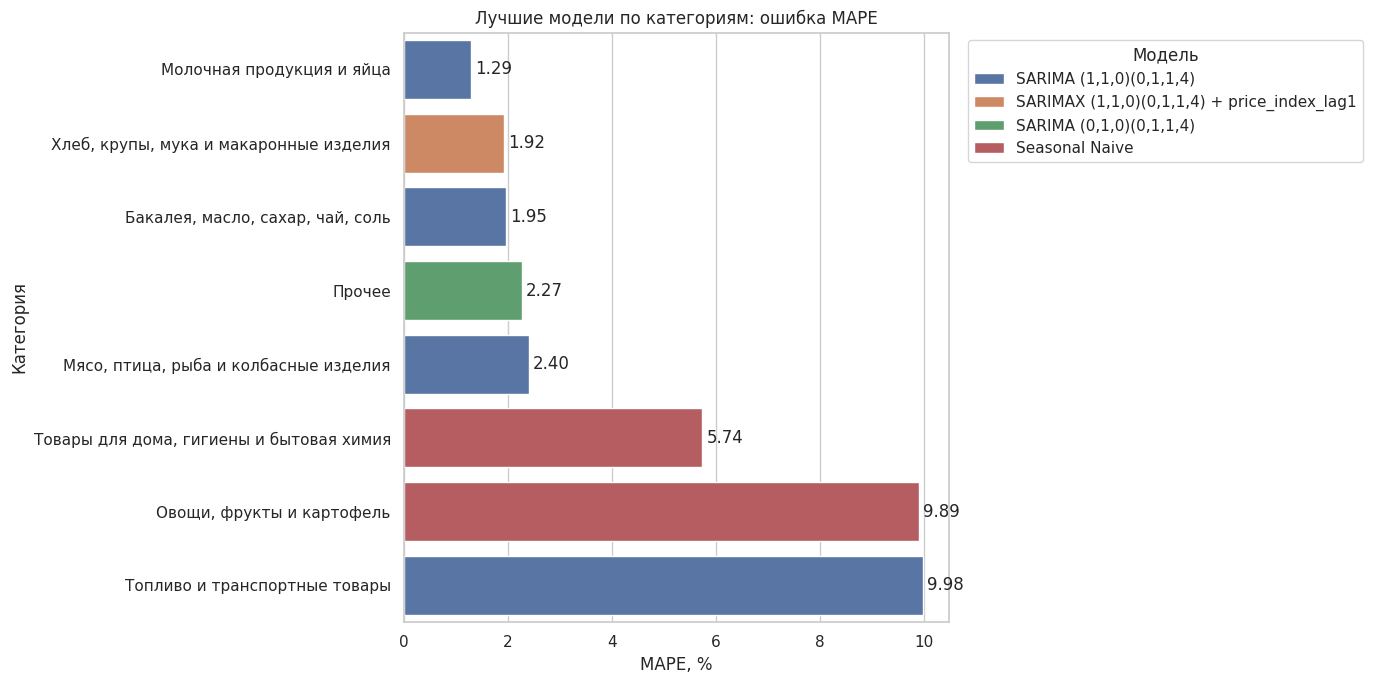

In [39]:
plt.figure(figsize=(14, 7))

plot_data = best_models_by_category.sort_values("MAPE", ascending=True)

ax = sns.barplot(
    data=plot_data,
    x="MAPE",
    y="product_group_name",
    hue="model",
    dodge=False
)

plt.title("Лучшие модели по категориям: ошибка MAPE")
plt.xlabel("MAPE, %")
plt.ylabel("Категория")
plt.legend(title="Модель", bbox_to_anchor=(1.02, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

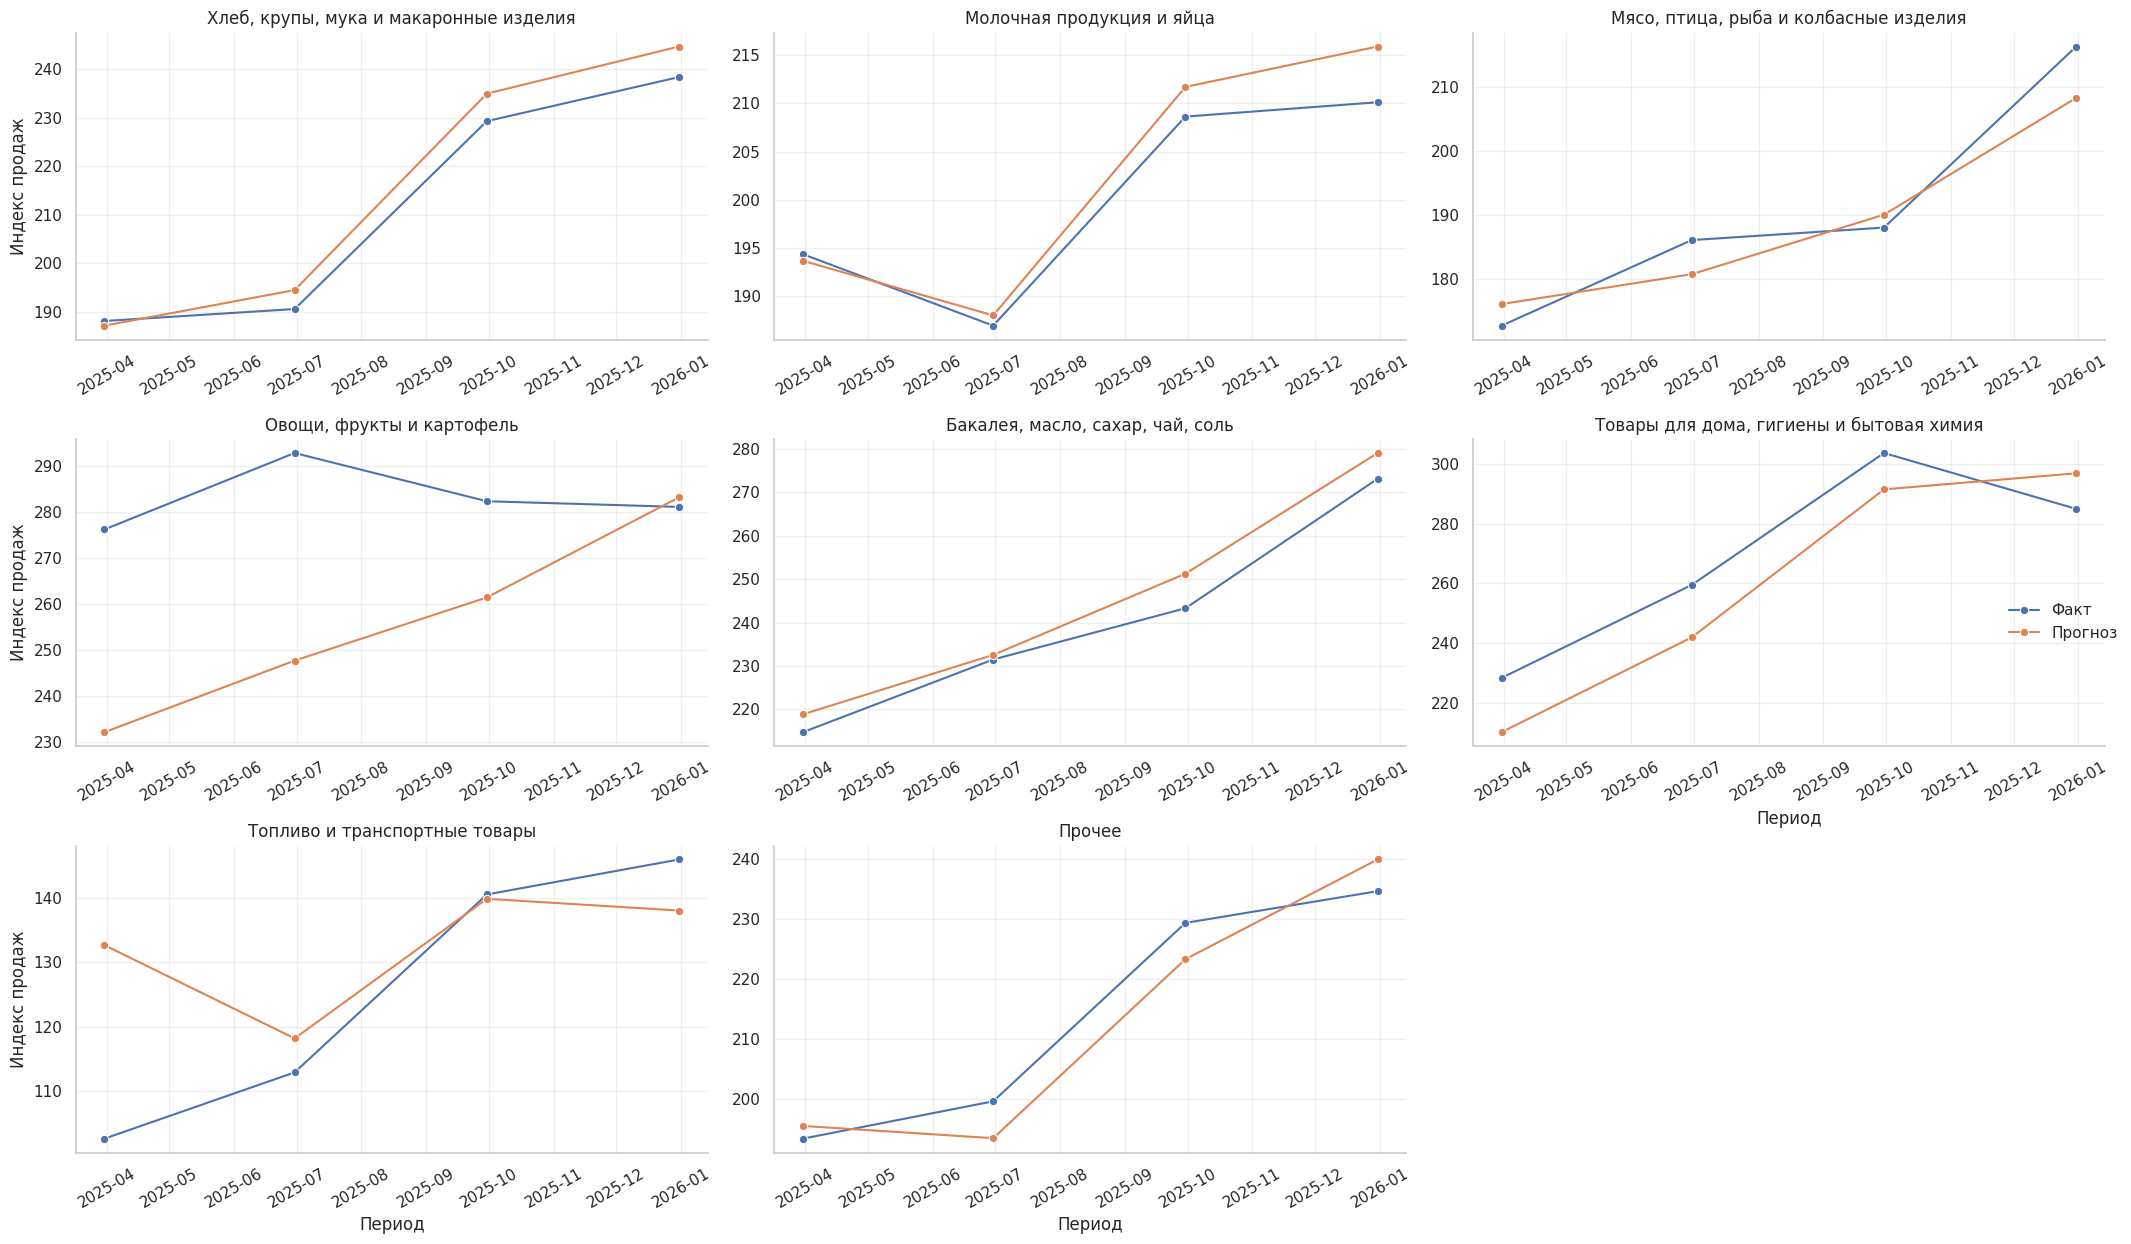

In [40]:
best_keys = best_models_by_category[
    ["product_group_code", "model"]
].copy()

best_predictions = model_predictions_df.merge(
    best_keys,
    on=["product_group_code", "model"],
    how="inner"
)

best_predictions_plot = best_predictions.copy()

plot_df = pd.concat(
    [
        best_predictions_plot[
            ["period_end", "product_group_name", "y"]
        ].rename(columns={"y": "value"}).assign(series="Факт"),
        best_predictions_plot[
            ["period_end", "product_group_name", "yhat"]
        ].rename(columns={"yhat": "value"}).assign(series="Прогноз")
    ],
    ignore_index=True
)

g = sns.FacetGrid(
    plot_df,
    col="product_group_name",
    col_wrap=3,
    height=4.2,
    aspect=1.6,
    hue="series",
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="period_end",
    y="value",
    marker="o"
)

g.add_legend(title="")
g.set_axis_labels("Период", "Индекс продаж")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
model_type_compare = model_metrics_df.copy()

model_type_compare["model_type"] = np.where(
    model_type_compare["model"].str.contains("Naive", case=False),
    "Seasonal Naive",
    np.where(
        model_type_compare["model"].str.contains("SARIMAX", case=False),
        "SARIMAX",
        "SARIMA"
    )
)

model_type_summary = (
    model_type_compare
    .groupby("model_type", as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_MAPE=("MAPE", "mean"),
        mean_sMAPE=("sMAPE", "mean")
    )
)

display(model_type_summary.round(3))

,model_type,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE
0,SARIMA,14.321,16.458,6.216,5.832
1,SARIMAX,18.825,21.211,8.205,7.591
2,Seasonal Naive,23.899,26.920,12.946,12.132


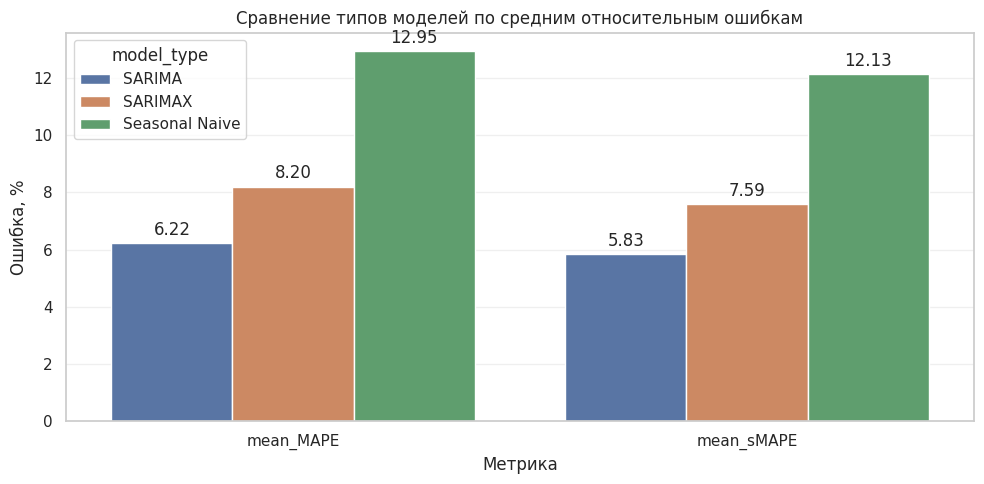

In [42]:
model_type_long = model_type_summary.melt(
    id_vars="model_type",
    value_vars=["mean_MAPE", "mean_sMAPE"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=model_type_long,
    x="metric",
    y="value",
    hue="model_type"
)

plt.title("Сравнение типов моделей по средним относительным ошибкам")
plt.xlabel("Метрика")
plt.ylabel("Ошибка, %")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

In [43]:
check_train_periods = (
    model_metrics_df[
        [
            "model",
            "product_group_code",
            "product_group_name",
            "train_start",
            "train_end",
            "valid_start",
            "valid_end",
            "MAPE"
        ]
    ]
    .copy()
)

check_train_periods["train_end"] = pd.to_datetime(check_train_periods["train_end"])
check_train_periods["valid_start"] = pd.to_datetime(check_train_periods["valid_start"])
check_train_periods["valid_end"] = pd.to_datetime(check_train_periods["valid_end"])

display(
    check_train_periods
    .sort_values(["product_group_code", "model"])
)

,model,product_group_code,product_group_name,train_start,train_end,valid_start,valid_end,MAPE
1,"SARIMA (0,1,0)(0,1,1,4)",G01,"Хлеб, крупы, мука и макаронные изделия",2017-06-30,2024-12-31,2025-03-31,2025-12-31,2.540169
2,"SARIMA (1,1,0)(0,1,1,4)",G01,"Хлеб, крупы, мука и макаронные изделия",2017-06-30,2024-12-31,2025-03-31,2025-12-31,3.150049
3,"SARIMAX (0,1,0)(0,1,1,4) + price_index_lag1",G01,"Хлеб, крупы, мука и макаронные изделия",2017-06-30,2024-12-31,2025-03-31,2025-12-31,2.732055
4,"SARIMAX (1,1,0)(0,1,1,4) + price_index_lag1",G01,"Хлеб, крупы, мука и макаронные изделия",2017-06-30,2024-12-31,2025-03-31,2025-12-31,1.919019
0,Seasonal Naive,G01,"Хлеб, крупы, мука и макаронные изделия",2017-06-30,2024-12-31,2025-03-31,2025-12-31,13.804125
6,"SARIMA (0,1,0)(0,1,1,4)",G02,Молочная продукция и яйца,2017-06-30,2024-12-31,2025-03-31,2025-12-31,2.562678
7,"SARIMA (1,1,0)(0,1,1,4)",G02,Молочная продукция и яйца,2017-06-30,2024-12-31,2025-03-31,2025-12-31,1.285510
8,"SARIMAX (0,1,0)(0,1,1,4) + price_index_lag1",G02,Молочная продукция и яйца,2017-06-30,2024-12-31,2025-03-31,2025-12-31,6.550387
9,"SARIMAX (1,1,0)(0,1,1,4) + price_index_lag1",G02,Молочная продукция и яйца,2017-06-30,2024-12-31,2025-03-31,2025-12-31,3.613553
5,Seasonal Naive,G02,Молочная продукция и яйца,2017-06-30,2024-12-31,2025-03-31,2025-12-31,9.161513


In [44]:
leak_check = check_train_periods.copy()

leak_check["train_uses_2025"] = leak_check["train_end"].dt.year >= 2025
leak_check["validation_is_2025"] = (
    (leak_check["valid_start"].dt.year == 2025) &
    (leak_check["valid_end"].dt.year == 2025)
)

display(
    leak_check[
        [
            "model",
            "product_group_code",
            "product_group_name",
            "train_end",
            "valid_start",
            "valid_end",
            "train_uses_2025",
            "validation_is_2025"
        ]
    ]
)

print("Есть ли обучение на 2025 году?")
print(leak_check["train_uses_2025"].any())

,model,product_group_code,product_group_name,train_end,valid_start,valid_end,train_uses_2025,validation_is_2025
0,Seasonal Naive,G01,"Хлеб, крупы, мука и макаронные изделия",2024-12-31,2025-03-31,2025-12-31,False,True
1,"SARIMA (0,1,0)(0,1,1,4)",G01,"Хлеб, крупы, мука и макаронные изделия",2024-12-31,2025-03-31,2025-12-31,False,True
2,"SARIMA (1,1,0)(0,1,1,4)",G01,"Хлеб, крупы, мука и макаронные изделия",2024-12-31,2025-03-31,2025-12-31,False,True
3,"SARIMAX (0,1,0)(0,1,1,4) + price_index_lag1",G01,"Хлеб, крупы, мука и макаронные изделия",2024-12-31,2025-03-31,2025-12-31,False,True
4,"SARIMAX (1,1,0)(0,1,1,4) + price_index_lag1",G01,"Хлеб, крупы, мука и макаронные изделия",2024-12-31,2025-03-31,2025-12-31,False,True
5,Seasonal Naive,G02,Молочная продукция и яйца,2024-12-31,2025-03-31,2025-12-31,False,True
6,"SARIMA (0,1,0)(0,1,1,4)",G02,Молочная продукция и яйца,2024-12-31,2025-03-31,2025-12-31,False,True
7,"SARIMA (1,1,0)(0,1,1,4)",G02,Молочная продукция и яйца,2024-12-31,2025-03-31,2025-12-31,False,True
8,"SARIMAX (0,1,0)(0,1,1,4) + price_index_lag1",G02,Молочная продукция и яйца,2024-12-31,2025-03-31,2025-12-31,False,True
9,"SARIMAX (1,1,0)(0,1,1,4) + price_index_lag1",G02,Молочная продукция и яйца,2024-12-31,2025-03-31,2025-12-31,False,True


Есть ли обучение на 2025 году?
False


In [45]:
validation_size = 4

split_check = []

for group_code, category_df in arimax_data.groupby("product_group_code"):
    category_df = category_df.sort_values("period_end").reset_index(drop=True)

    train_df = category_df.iloc[:-validation_size].copy()
    valid_df = category_df.iloc[-validation_size:].copy()

    split_check.append({
        "product_group_code": group_code,
        "product_group_name": category_df["product_group_name"].iloc[0],
        "train_start": train_df["period_end"].min(),
        "train_end": train_df["period_end"].max(),
        "train_years": sorted(train_df["year"].unique()),
        "valid_start": valid_df["period_end"].min(),
        "valid_end": valid_df["period_end"].max(),
        "valid_years": sorted(valid_df["year"].unique()),
        "train_has_2025": 2025 in train_df["year"].unique(),
        "valid_only_2025": set(valid_df["year"].unique()) == {2025}
    })

split_check_df = pd.DataFrame(split_check)

display(split_check_df)

print("Есть категории, где train содержит 2025?")
print(split_check_df["train_has_2025"].any())

print("У всех категорий validation только 2025?")
print(split_check_df["valid_only_2025"].all())

,product_group_code,product_group_name,train_start,train_end,train_years,valid_start,valid_end,valid_years,train_has_2025,valid_only_2025
0,G01,"Хлеб, крупы, мука и макаронные изделия",2017-06-30,2024-12-31,"[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]",2025-03-31,2025-12-31,[2025],False,True
1,G02,Молочная продукция и яйца,2017-06-30,2024-12-31,"[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]",2025-03-31,2025-12-31,[2025],False,True
2,G03,"Мясо, птица, рыба и колбасные изделия",2017-06-30,2024-12-31,"[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]",2025-03-31,2025-12-31,[2025],False,True
3,G04,"Овощи, фрукты и картофель",2017-06-30,2024-12-31,"[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]",2025-03-31,2025-12-31,[2025],False,True
4,G05,"Бакалея, масло, сахар, чай, соль",2017-06-30,2024-12-31,"[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]",2025-03-31,2025-12-31,[2025],False,True
5,G07,"Товары для дома, гигиены и бытовая химия",2017-06-30,2024-12-31,"[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]",2025-03-31,2025-12-31,[2025],False,True
6,G10,Топливо и транспортные товары,2017-06-30,2024-12-31,"[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]",2025-03-31,2025-12-31,[2025],False,True
7,G99,Прочее,2017-06-30,2024-12-31,"[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]",2025-03-31,2025-12-31,[2025],False,True


Есть категории, где train содержит 2025?
False
У всех категорий validation только 2025?
True
